# 1. Geração do Gêmeo Digital com Dependência Causal

Como o hardware da planta física (ESP32 e sensores) ainda está em fase de comissionamento, rodamos esta análise usando um Gêmeo Digital (Mock Data). Diferente de dados aleatórios, modelamos uma relação matemática onde a atuação da bomba (PWM) impacta diretamente o peso lido, simulando o comportamento real do sistema.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Semente para garantir que os resultados sejam constantes em cada execução
np.random.seed(42)
qtd_dados = 1000

# Modelagem Causal: O PWM dita a dinâmica do enchimento do tanque
pwm_bomba = np.random.uniform(50, 255, qtd_dados)

# O modelo assume um comportamento linear na faixa de operação da bomba (PWM * 0.4)
# Adicionamos um ruído de 3g para simular a vibração mecânica real
peso_sensor = 400 + (pwm_bomba * 0.4) + np.random.normal(0, 3, qtd_dados)
setpoint = 500
erro_pid = setpoint - peso_sensor

df = pd.DataFrame({
    'tempo': pd.date_range(start='2026-04-14', periods=qtd_dados, freq='s'),
    'setpoint_alvo': setpoint,
    'peso_sensor': peso_sensor,
    'pwm_bomba': pwm_bomba,
    'erro_pid': erro_pid
})

# Inserindo falhas simuladas para testar o pipeline de limpeza (ETL)
df.loc[15:20, 'peso_sensor'] = np.nan
print("Dataset do Gêmeo Digital gerado com sucesso.")

Dataset do Gêmeo Digital gerado com sucesso.


# 2. Processamento de Dados (ETL) e Estatística

Nesta etapa, limpamos falhas de leitura do sensor e aplicamos o filtro **IQR (Amplitude Interquartil)**. Esse método é fundamental na engenharia para descartar outliers (leituras anômalas) que poderiam desestabilizar o controle ou enganar os modelos de IA.

In [ ]:
# Remoção de valores nulos e duplicatas
df_limpo = df.dropna().drop_duplicates()

# Cálculo do IQR para remoção de Outliers
Q1 = df_limpo['peso_sensor'].quantile(0.25)
Q3 = df_limpo['peso_sensor'].quantile(0.75)
IQR = Q3 - Q1
df_final = df_limpo[(df_limpo['peso_sensor'] >= (Q1 - 1.5 * IQR)) & (df_limpo['peso_sensor'] <= (Q3 + 1.5 * IQR))]

print("--- Estatística Descritiva (Pós-ETL) ---")
# Observa-se baixa variância no peso, indicando estabilidade da planta na faixa de operação
display(df_final.describe())

--- Estatística Descritiva (Pós-ETL) ---


,tempo,setpoint_alvo,peso_sensor,pwm_bomba,erro_pid
count,994,994.0,994.000000,994.000000,994.000000
mean,2026-04-14 00:08:22.409456640,500.0,460.540404,150.625121,39.459596
min,2026-04-14 00:00:00,500.0,415.034019,50.949565,-5.894843
25%,2026-04-14 00:04:14.249999872,500.0,439.019063,97.860575,19.268348
50%,2026-04-14 00:08:22.500000,500.0,461.379893,152.050669,38.620107
75%,2026-04-14 00:12:30.750000128,500.0,480.731652,202.908173,60.980937
max,2026-04-14 00:16:39,500.0,505.894843,254.942123,84.965981
std,NaN,0.0,24.050163,60.002518,24.050163


# 3. Análise Visual e Validação de Hipóteses

Geramos visualizações complexas para validar a controlabilidade da planta e identificar o comportamento do sensor de carga em relação ao atuador.

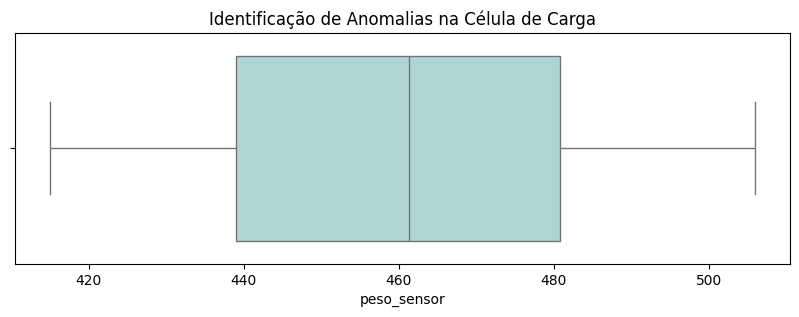

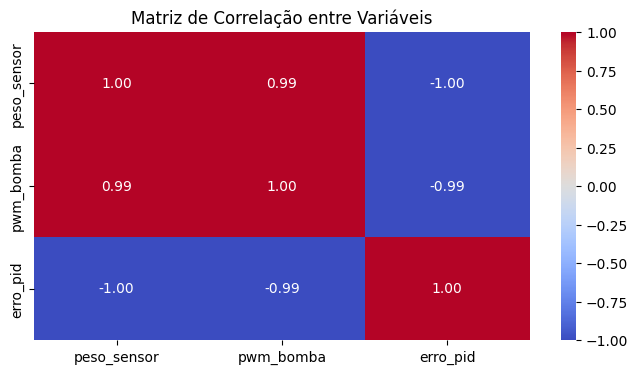

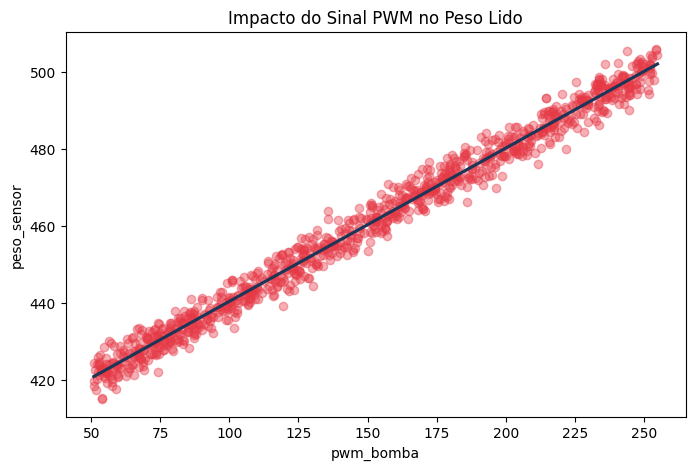

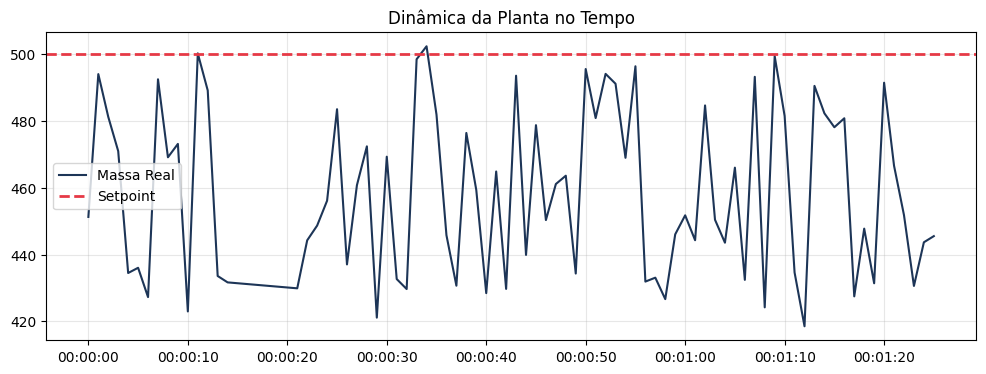

In [ ]:
# Gráfico 1: Boxplot para integridade do sensor
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_final['peso_sensor'], color='#A8DADC')
plt.title('Identificação de Anomalias na Célula de Carga')
plt.show()

# Gráfico 2: Heatmap de Correlação Causal
plt.figure(figsize=(8, 4))
sns.heatmap(df_final[['peso_sensor', 'pwm_bomba', 'erro_pid']].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Variáveis')
plt.show()

# Gráfico 3: Regressão Linear (Atuador vs Processo)
plt.figure(figsize=(8, 5))
sns.regplot(x='pwm_bomba', y='peso_sensor', data=df_final,
            scatter_kws={'alpha':0.4, 'color':'#E63946'}, line_kws={'color':'#1D3557'})
plt.title('Impacto do Sinal PWM no Peso Lido')
plt.show()

# Gráfico 4: Série Temporal
plt.figure(figsize=(12, 4))
plt.plot(df_final['tempo'][:80], df_final['peso_sensor'][:80], label='Massa Real', color='#1D3557')
plt.axhline(y=500, color='#E63946', linestyle='--', label='Setpoint', linewidth=2)
plt.title('Dinâmica da Planta no Tempo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Conclusão da Análise Exploratória (EDA)

A análise pode comprovar que o modelo de Gêmeo Digital construído apresenta coerência física com sistemas reais de dosagem industrial.

A forte correlação positiva entre a variável de atuação (PWM) e a variável de processo (peso) confirma a controlabilidade da planta, enquanto a relação inversa com o erro evidencia o comportamento esperado de uma malha de controle PID. O uso do filtro IQR garantiu a integridade estatística dos dados, removendo leituras anômalas.

Esses resultados validam a viabilidade do dataset para as próximas etapas de modelagem de Inteligência Artificial.